<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hierarchical Clustering**

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv(
    '/content/drive/MyDrive/movies_metadata.csv',
    sep=',',
    engine='python',
    quoting=3,
    on_bad_lines='skip'
)

print(df.shape)
print(df.columns)
df.head()

(33390, 24)
Index(['"adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count"'],
      dtype='object')


"adult  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                         tt0114709   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                                                   Grumpier Old Men   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                                        ""Cheated on   
       ""{'id': 96871   'name': 'Father of the Bride Collection'  'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg' 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.... 0          ""[{'id': 35      'name': 'Comedy'}]"" NaN                    11862                 tt0113041     en                    Father of the Bride Part II          ""Just when George Banks has recovered from his...   he receives the news that she's pregnant ... ...   
       NaN             62000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   9087          tt0112346             en                                   The American President                                       ""Widowed U.S. president Andrew Shepherd   

                                                                                                                                                                                                                                                                                                                                                                                                                               belongs_to_collection  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                                en   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                  ""A family wedding reignites the ancient feud ...   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                           mistreated and stepped on   
       ""{'id': 96871   'name

In [39]:
df = df[['title','overview','genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [40]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [41]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [42]:
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000)

X = tfidf.fit_transform(df['tags'])

In [44]:
from sklearn.decomposition import PCA

X_dense = X.toarray()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X_dense)

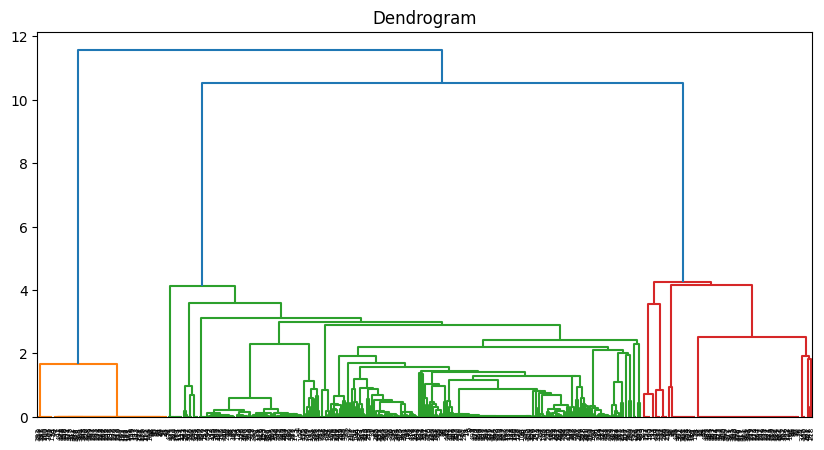

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_reduced[:500]

linked = linkage(sample, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [46]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

k_values = [5, 8, 10, 12]

scores = {}

for k in k_values:
    hc = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(sample)

    score = silhouette_score(sample, labels)
    scores[k] = score

    print(f"K={k} → Silhouette Score: {score:.4f}")

K=5 → Silhouette Score: 0.5801
K=8 → Silhouette Score: 0.5902
K=10 → Silhouette Score: 0.4469
K=12 → Silhouette Score: 0.4822


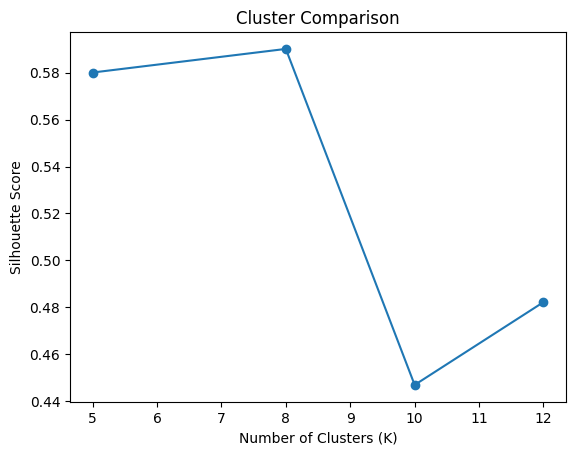

In [47]:
plt.figure()
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Cluster Comparison")
plt.show()

In [49]:
valid_df = df[df['title'].str.strip().str.len() > 1].copy().reset_index(drop=True)

mask = df['title'].str.strip().str.len() > 1
X_reduced_valid = X_reduced[mask.values]

sample = X_reduced_valid[:500]
df_sample = valid_df.iloc[:len(sample)].copy()

from sklearn.cluster import AgglomerativeClustering
best_k = 10
hc = AgglomerativeClustering(n_clusters=best_k)
df_sample['cluster'] = hc.fit_predict(sample)

df_sample['title'] = df_sample['title'].astype(str).str.lower()
indices = {title: idx for idx, title in enumerate(df_sample['title'])}

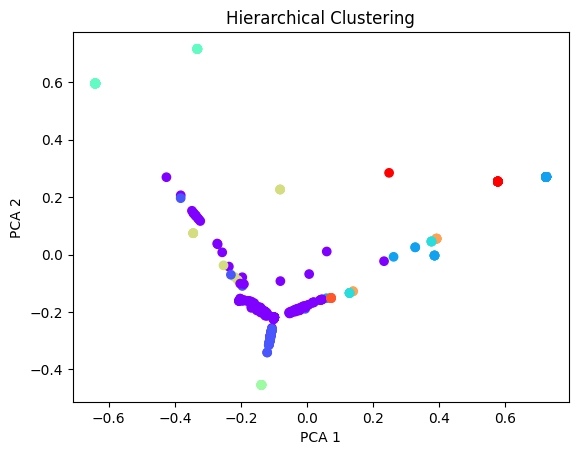

In [50]:
plt.figure()
plt.scatter(sample[:,0], sample[:,1], c=df_sample['cluster'], cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [51]:
final_score = silhouette_score(sample, df_sample['cluster'])
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.4468523520896649


In [52]:
df_sample['title'] = df_sample['title'].astype(str).str.lower()

df_sample = df_sample.drop_duplicates(subset='title').reset_index(drop=True)

indices = {title: idx for idx, title in enumerate(df_sample['title'])}

In [53]:
def recommend_cluster(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "❌ Movie not found"

    idx = indices[movie_name]

    # Safety check (VERY IMPORTANT)
    if idx >= len(df_sample):
        return "❌ Movie not in clustering sample (try another)"

    cluster_id = df_sample.iloc[idx]['cluster']

    recs = df_sample[df_sample['cluster'] == cluster_id]

    recs = recs.drop(index=idx, errors='ignore')

    print(f"\n🎬 Input Movie: {movie_name}")
    print(f"📊 Cluster: {cluster_id}")
    print("\nRecommended Movies:\n")

    for i, movie in enumerate(recs['title'].head(top_n), 1):
        print(f"{i}. {movie}")

In [58]:
movie = input("Enter movie name: ")
recommend_cluster(movie)

Enter movie name: toy story

🎬 Input Movie: toy story
📊 Cluster: 0

Recommended Movies:

1. waiting to exhale
2. 72"
3. casino
4. 224"
5. 199"
6. now and then
7. clueless
8. 50"
9. 30"
10. georgia


In [59]:
# Show cluster distribution
print(df_sample['cluster'].value_counts())

cluster
0    142
4     61
2     26
1     17
9      8
3      7
7      4
6      3
8      3
Name: count, dtype: int64


In [60]:
for c in df_sample['cluster'].unique():
    print(f"Cluster {c} → {df_sample[df_sample['cluster']==c]['title'].head(5).values}")

Cluster 0 → ['toy story' 'waiting to exhale' '72"' 'casino' '224"']
Cluster 1 → ['false' 'desperado' 'jeffrey' 'the scarlet letter' 'dumb and dumber']
Cluster 4 → ['364"' '365"' '113"' '9"' '45"']
Cluster 7 → ['persuasion' 'black beauty' '7.5' '5.2']
Cluster 3 → ['6.5' "the young poisoner's handbook" '464"' 'la collectionneuse' '510"']
Cluster 2 → ['6.4' '5.9' 'two if by sea' '5.1' '5.5']
Cluster 9 → ['5.8' '4.3' '7.0' '5.3' '6.3']
Cluster 6 → ['5"' '1230"' '15"']
Cluster 8 → ['13"' '160"' '606"']
